In [1]:
import pandas as pd
import numpy as np
kenya=pd.read_csv("../data/kenya.csv",skipfooter=10)
kenya.head()

/tmp/ipykernel_99592/2347981755.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  kenya=pd.read_csv("../data/kenya.csv",skipfooter=10)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [ ]:
# missing value
kenya.replace(-999,np.nan,inplace=True)
print(f" Messing Value found:\n {kenya.isnull().sum()}")

 Messing Value found:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [7]:
# date conversion
kenya["DATE"]=pd.to_datetime(kenya["YEAR"]*1000+kenya["DOY"],format= "%Y%j")
kenya["MONTH"]=kenya["DATE"].dt.month
kenya.set_index("DATE",inplace=True)
kenya.head()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,MONTH
DATE,,,,,,,,,,,,,
2015-01-01,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,1
2015-01-02,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,1
2015-01-03,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,1
2015-01-04,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,1
2015-01-05,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,1


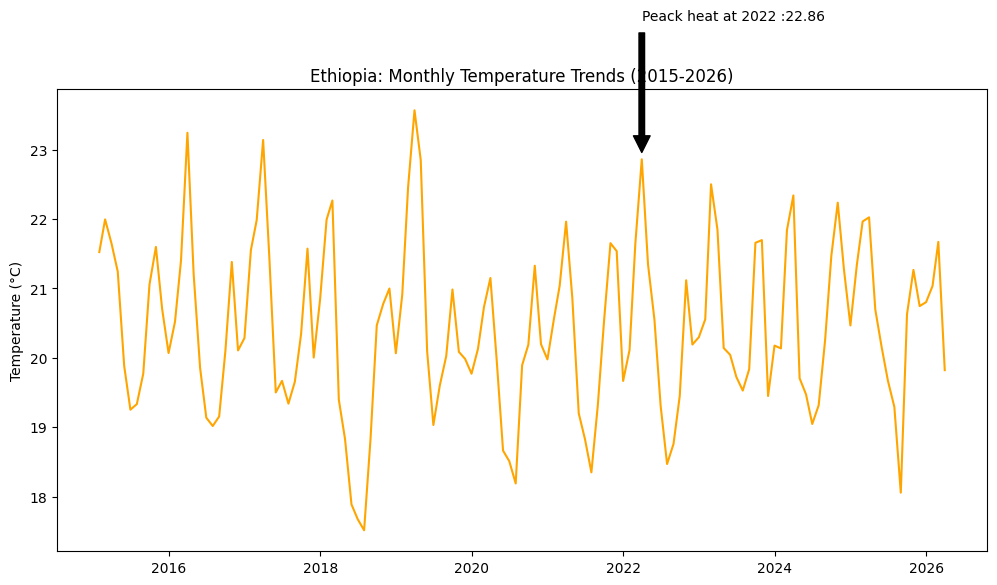

In [12]:
# Monthly Temperature Line Chart
import matplotlib.pyplot as plt
# resample monthely averagy
monthly_temp=kenya["T2M"].resample('ME').mean()
plt.figure(figsize=(12,6))
plt.plot(monthly_temp,label="Mean Temp ",color='orange')
# annotate the hotest month in 2022
hottest_2022=monthly_temp["2022"].idxmax()
temp_max=monthly_temp['2022'].max()
plt.annotate(f"Peack heat at 2022 :{temp_max:.2f}",
             xy=(hottest_2022,temp_max),
             xytext=(hottest_2022,temp_max+2),
             arrowprops=dict(facecolor='black',shrink=0.05))
plt.title('Ethiopia: Monthly Temperature Trends (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.show()
